# Plotting Magnetic Field Equilibrium of FPP (Fusion Pilot Plant)

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))

import desc.io

In [7]:
%matplotlib inline
from desc.plotting import plot_comparison, plot_section


In [2]:
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.profiles import PowerSeriesProfile


In [3]:
surf2 = FourierRZToroidalSurface(
    R_lmn=[10.0, -1.0, -0.3, 0.3],
    modes_R=[
        (0, 0),
        (1, 0),
        (1, 1),
        (-1, -1),
    ],  # (m,n) pairs corresponding to R_mn on previous line
    Z_lmn=[1, -0.3, -0.3],
    modes_Z=[(-1, 0), (-1, 1), (1, -1)],
    NFP=19,
)

pressure = PowerSeriesProfile(
    [1.8e4, 0, -3.6e4, 0, 1.8e4]
)  # coefficients in ascending powers of rho
iota = PowerSeriesProfile([1, 0, 1.5])  # 1 + 1.5 r^2

eq = Equilibrium(
    L=8,  # radial resolution
    M=8,  # poloidal resolution
    N=3,  # toroidal resolution
    surface=surf2,
    pressure=pressure,
    iota=iota,
    Psi=1.0,  # total flux, in Webers
)

In [4]:
eq1, info = eq.solve(verbose=3, copy=True)

Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 1.13 sec
Timer: Objective build = 1.93 sec
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 1.09 sec
Timer: LinearConstraintProjection build = 5.21 sec
Number of parameters: 351
Number of objectives: 2106
Timer: Initializing the optimization = 8.29 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Tru

In [5]:
from desc.continuation import solve_continuation_automatic

eqf = solve_continuation_automatic(eq.copy(), verbose=3)

Step 1
Spectral indexing: ansi
Spectral resolution (L,M,N)=(6,6,0)
Node resolution (L,M,N)=(12,12,0)
Boundary ratio = 0
Pressure ratio = 0
Perturbation Order = 2
Objective: force
Optimizer: lsq-exact
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 1.02 sec
Timer: Objective build = 1.24 sec
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 566 ms
Timer: LinearConstraintProjection build = 3.56 sec
Number of parameters: 27
Number of objectives: 98
Timer: Initializing the optimization = 5.43 sec

Starting optimization
Using method: lsq-exact
Solver options:
-----------------------------------------

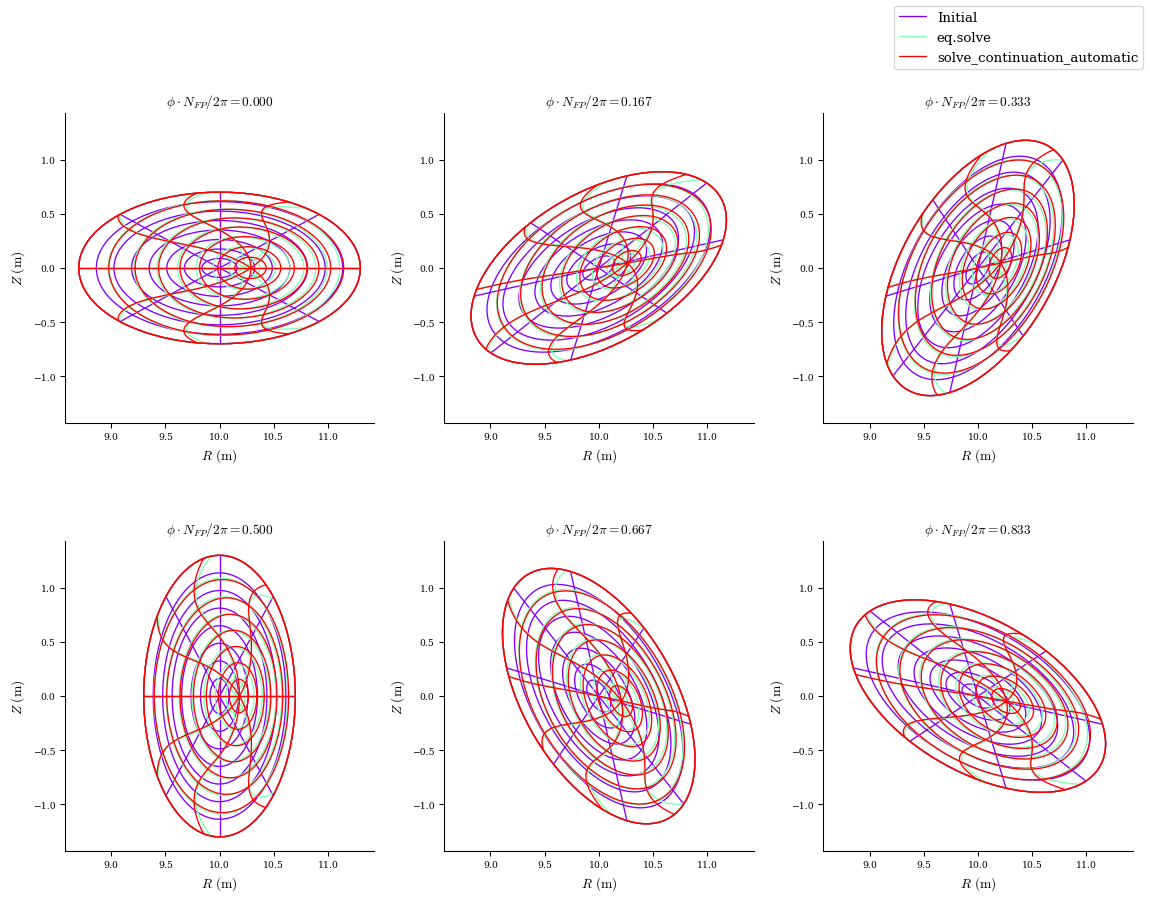

In [8]:
plot_comparison(
    [eq, eq1, eqf[-1]], labels=["Initial", "eq.solve", "solve_continuation_automatic"]
);